# UQ Algorithms applied to Field Quantities
To seperate the effect of FEM discretisation and UQ errors, we now skip the FEM solving and instead derrive QoIs based the underlying Gaussian random field. 
To do this, we generate a Gaussian field as 
\begin{equation*}
    G(x,y, \xi) = \mu + \sigma \sum_{j=1}^{d_\text{trunc}} c_j \xi_j \phi_j(x,y), \quad \xi_j \sim U[-1,1].
\end{equation*}
An easy to calculate exact quantity of interest is then simply given as the mean of the field, hence 
\begin{equation*}
    \mathbb{E}_{\text{gaussian}} [Q] = \mu.
\end{equation*}
We now further threshold the field as 
\begin{equation*}
    \kappa(x,y,\xi)=
    \begin{cases}
        2, & G(x,y,\xi)\le \mu,\\
        3, & G(x,y,\xi)>\mu.
    \end{cases}
\end{equation*}
By the symmetric construction we immediatly obtain 
\begin{equation*}
    \mathbb{E}_{\text{2-phase}} [Q] = \frac12 (2 + 3) = 2.5,
\end{equation*}
which allows to use two exact reference solutions.

In [1]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

font_size=12
title_size=14
label_size=13
tick_size=11
legend_size=10
dpi=300


plt.rcParams.update({
    "figure.dpi": dpi,
    "savefig.dpi": dpi,
    "font.size": font_size,
    "axes.titlesize": title_size,
    "axes.labelsize": label_size,
    "xtick.labelsize": tick_size,
    "ytick.labelsize": tick_size,
    "legend.fontsize": legend_size,
    "figure.titlesize": title_size + 1,
    "lines.linewidth": 2.0,
    "lines.markersize": 6.0,
    "text.usetex": False
})

import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parents[1]  # if notebook is in configs/notebooks/
sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
from itertools import product
from tqdm import tqdm
import pandas as pd
import Tasmanian
import os

from uq.sparseGridSC import SparseGridSC

In [2]:
class GaussianFourierField:
    """
    G(x, y, xi) = mu + sigma * sum_i c_i xi_i phi_i(x, y),
    xi_i ~ U[-1, 1].
    """

    def __init__(
        self,
        dim,
        corrLength=0.001,
        mu=1.0,
        sigma=0.25,
        domain=((0.0, 1.0), (0.0, 1.0)),
        normalize=True,
    ):
        self.dim = dim
        self.corrLength = corrLength
        self.mu = mu
        self.sigma = sigma
        self.domain = domain
        self.normalize = normalize

        self.modes = self.build_modes(dim)
        self.coeffs = self.build_coeffs(self.modes)

    def build_modes(self, dim):
        max_freq = int(np.ceil(np.sqrt(dim))) + 3

        modes = [
            (m, n)
            for m in range(max_freq)
            for n in range(max_freq)
            if not (m == 0 and n == 0)
        ]

        modes.sort(key=lambda mn: mn[0] ** 2 + mn[1] ** 2)
        return modes[:dim]

    def build_coeffs(self, modes):
        coeffs = []

        for m, n in modes:
            lam = m**2 + n**2
            c = np.exp(-0.5 * (np.pi * self.corrLength) ** 2 * lam)
            coeffs.append(c)

        coeffs = np.asarray(coeffs, dtype=float)

        if self.normalize:
            variance = np.sum(coeffs**2) / 3.0
            coeffs = coeffs / np.sqrt(variance)

        return coeffs

    def evaluate(self, x, y, xi):
        xi = np.asarray(xi, dtype=float)

        if xi.shape[0] != self.dim:
            raise ValueError(f"Expected xi of length {self.dim}, got {xi.shape[0]}.")

        x = np.asarray(x)
        y = np.asarray(y)

        x0, x1 = self.domain[0]
        y0, y1 = self.domain[1]

        xhat = (x - x0) / (x1 - x0)
        yhat = (y - y0) / (y1 - y0)

        G = np.zeros_like(xhat, dtype=float)

        for xi_i, c_i, (m, n) in zip(xi, self.coeffs, self.modes):
            phi = np.cos(np.pi * m * xhat) * np.cos(np.pi * n * yhat)
            G += c_i * xi_i * phi

        return self.mu + self.sigma * G


class SmoothGaussianMeanProblem:
    """
    QoI:
        Q(xi) = mean_D G(x, xi)

    Exact reference:
        E[Q] = mu
    """

    def __init__(self, field, grid_size=256):
        self.field = field

        x = np.linspace(0.0, 1.0, grid_size)
        y = np.linspace(0.0, 1.0, grid_size)
        self.X, self.Y = np.meshgrid(x, y, indexing="ij")

    def qoi(self, xi):
        G = self.field.evaluate(self.X, self.Y, xi)
        return np.asarray([np.mean(G)], dtype=float)


class FixedTwoPhaseGaussianMeanProblem:
    """
    K(x, xi) = k1 if G(x, xi) <= mu
             = k2 if G(x, xi) >  mu

    QoI:
        Q(xi) = mean_D K(x, xi)

    Exact reference for threshold = mu:
        E[Q] = 0.5*k1 + 0.5*k2
    """

    def __init__(self, field, threshold=None, values=(2.0, 3.0), grid_size=256):
        self.field = field
        self.threshold = field.mu if threshold is None else threshold
        self.values = values

        x = np.linspace(0.0, 1.0, grid_size)
        y = np.linspace(0.0, 1.0, grid_size)
        self.X, self.Y = np.meshgrid(x, y, indexing="ij")

    def qoi(self, xi):
        G = self.field.evaluate(self.X, self.Y, xi)
        K = np.where(G <= self.threshold, self.values[0], self.values[1])
        return np.asarray([np.mean(K)], dtype=float)


In [3]:
sc_methods = [
    dict(
        method="SCClenshaw",
        gridType="level",
        rule="clenshaw-curtis",
        localDegree=None,
    ),
    dict(
        method="SCLocalDegree1",
        gridType="local",
        rule=None,
        localDegree=1,
    ),
    dict(
        method="SCLocalDegree2",
        gridType="local",
        rule=None,
        localDegree=2,
    ),
]

In [4]:
def point_key(x, ndigits=14):
    return tuple(np.round(np.asarray(x, dtype=float), ndigits))


def build_tasmanian_grid(dim, level, sc_cfg):
    grid = Tasmanian.SparseGrid()

    if sc_cfg["gridType"] == "local":
        grid.makeLocalPolynomialGrid(
            dim,
            0,
            level,
            sc_cfg["localDegree"],
            "localp",
        )
    else:
        grid.makeGlobalGrid(
            dim,
            0,
            level,
            sc_cfg["gridType"],
            sc_cfg["rule"],
        )

    points = grid.getPoints()
    weights = grid.getQuadratureWeights()
    weights = weights / np.sum(weights)

    return points, weights


def nested_sc_method_runs(problem, dim, sc_cfg, levels):
    """
    For one SC method:
      1. Build finest level.
      2. Evaluate QoI once on every finest-level point.
      3. For each lower level, reuse matching point values and level weights.
    """

    levels = sorted(levels)
    finest_level = max(levels)

    finest_points, _ = build_tasmanian_grid(
        dim=dim,
        level=finest_level,
        sc_cfg=sc_cfg,
    )

    # Evaluate finest grid once
    cache = {}

    for p in tqdm(
        finest_points,
        total=len(finest_points),
        desc=f"{sc_cfg['method']} d={dim} finest L={finest_level}"
    ):
        cache[point_key(p)] = problem.qoi(p)

    results = []

    # Reuse for all levels
    for level in levels:

        points, weights = build_tasmanian_grid(
            dim=dim,
            level=level,
            sc_cfg=sc_cfg,
        )

        values = []

        for p in points:
            key = point_key(p)

            # Should normally be present due to nestedness.
            # Fallback protects against non-nested edge cases.
            if key not in cache:
                cache[key] = problem.qoi(p)

            values.append(cache[key])

        values = np.asarray(values)
        mean = weights @ values

        results.append({
            "method": sc_cfg["method"],
            "level": level,
            "N": len(points),
            "mean": mean,
        })

    return results

In [5]:
MAX_POINTS = 2500000
dimensions = [4, 5, 6, 7, 8, 9, 10]


corrLength = 0.1
mu = 1.0
sigma = 0.25
grid_size = 16

sc_methods = [
    dict(
        method="SCClenshaw",
        gridType="level",
        rule="clenshaw-curtis",
        localDegree=None,
    ),
    dict(
        method="SCLocalDegree1",
        gridType="local",
        rule=None,
        localDegree=1,
    ),
    dict(
        method="SCLocalDegree2",
        gridType="local",
        rule=None,
        localDegree=2,
    ),
]

rows = []


# ==========================================================
# Determine admissible SC levels per dimension and method
# ==========================================================

sc_runs = []

for dim in dimensions:
    for sc_cfg in sc_methods:

        level = 1

        while True:

            grid = Tasmanian.SparseGrid()

            if sc_cfg["gridType"] == "local":
                grid.makeLocalPolynomialGrid(
                    dim,
                    0,
                    level,
                    sc_cfg["localDegree"],
                    "localp",
                )
            else:
                grid.makeGlobalGrid(
                    dim,
                    0,
                    level,
                    sc_cfg["gridType"],
                    sc_cfg["rule"],
                )

            N = grid.getNumPoints()
            print(f"dim={dim}, current level={level}, nPoints={N}")

            if N > MAX_POINTS:
                break

            sc_runs.append({
                "dimension": dim,
                "method": sc_cfg["method"],
                "level": level,
                "N": N,
            })

            level += 1

sc_df = pd.DataFrame(sc_runs)

display(
    sc_df.pivot_table(
        index=["method", "level"],
        columns="dimension",
        values="N",
    )
)


# ==========================================================
# MC + SC runs
# ==========================================================

for dim in dimensions:

    print(f"\n{'=' * 80}")
    print(f"Dimension = {dim}")
    print(f"{'=' * 80}")

    max_sc_points = sc_df.loc[
        sc_df["dimension"] == dim,
        "N",
    ].max()

    rng = np.random.default_rng(12345)

    mc_points = rng.uniform(
        -1.0,
        1.0,
        size=(max_sc_points, dim),
    )

    # ------------------------------------------------------
    # Build problems for this dimension
    # ------------------------------------------------------

    smooth_field = GaussianFourierField(
        dim=dim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
    )

    twophase_field = GaussianFourierField(
        dim=dim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
    )

    problems = {
        "smooth Gaussian": {
            "problem": SmoothGaussianMeanProblem(
                smooth_field,
                grid_size=grid_size,
            ),
            "reference": np.asarray([mu]),
            "qoi_names": ["mean(G)"],
        },
        "fixed 2-phase Gaussian": {
            "problem": FixedTwoPhaseGaussianMeanProblem(
                twophase_field,
                threshold=mu,
                values=(2.0, 3.0),
                grid_size=grid_size,
            ),
            "reference": np.asarray([2.5]),
            "qoi_names": ["mean(K)"],
        },
    }

    # ------------------------------------------------------
    # MC
    # ------------------------------------------------------

    mc_sizes = sorted(
        n for n in [
            16, 32, 64, 128, 256, 512,
            1024, 2048, 4096, 8192,
            16384, 32768, 65536,
            131072, 262144, 524288,
        ]
        if n <= max_sc_points
    )

    for case_name, N in tqdm(
        product(problems.keys(), mc_sizes),
        total=len(problems) * len(mc_sizes),
        desc=f"MC d={dim}",
    ):

        cfg = problems[case_name]

        problem = cfg["problem"]
        reference = cfg["reference"]
        qoi_names = cfg["qoi_names"]

        values = np.asarray([
            problem.qoi(xi)
            for xi in mc_points[:N]
        ])

        mean = values.mean(axis=0)

        for qoi_id, qoi_name in enumerate(qoi_names):

            rows.append({
                "dimension": dim,
                "case": case_name,
                "method": "MC",
                "qoi": qoi_name,
                "qoi_id": qoi_id,
                "N": N,
                "scLevel": np.nan,
                "mean": mean[qoi_id],
                "reference": reference[qoi_id],
                "absError": abs(mean[qoi_id] - reference[qoi_id]),
            })


    # ------------------------------------------------------
    # SC with method-wise nested caching
    # ------------------------------------------------------

    dim_sc = sc_df[sc_df["dimension"] == dim].copy()

    for case_name, cfg in problems.items():

        problem = cfg["problem"]
        reference = cfg["reference"]
        qoi_names = cfg["qoi_names"]

        for sc_cfg in sc_methods:

            method = sc_cfg["method"]

            levels = dim_sc.loc[
                dim_sc["method"] == method,
                "level"
            ].astype(int).tolist()

            if len(levels) == 0:
                continue

            sc_results = nested_sc_method_runs(
                problem=problem,
                dim=dim,
                sc_cfg=sc_cfg,
                levels=levels,
            )

            for res in sc_results:

                level = res["level"]
                N = res["N"]
                mean = res["mean"]

                for qoi_id, qoi_name in enumerate(qoi_names):

                    rows.append({
                        "dimension": dim,
                        "case": case_name,
                        "method": method,
                        "qoi": qoi_name,
                        "qoi_id": qoi_id,
                        "N": N,
                        "scLevel": level,
                        "mean": mean[qoi_id],
                        "reference": reference[qoi_id],
                        "absError": abs(mean[qoi_id] - reference[qoi_id]),
                    })
# ==========================================================
# Save dataframe
# ==========================================================

df_test = pd.DataFrame(rows)

os.makedirs("pklFiles", exist_ok=True)

df_test.to_pickle("pklFiles/fieldQuantity.pkl")

print("\nSaved:")
print("pklFiles/fieldQuantity.pkl")

dim=4, current level=1, nPoints=9
dim=4, current level=2, nPoints=41
dim=4, current level=3, nPoints=137
dim=4, current level=4, nPoints=401
dim=4, current level=5, nPoints=1105
dim=4, current level=6, nPoints=2929
dim=4, current level=7, nPoints=7537
dim=4, current level=8, nPoints=18945
dim=4, current level=9, nPoints=46721
dim=4, current level=10, nPoints=113409
dim=4, current level=11, nPoints=271617
dim=4, current level=12, nPoints=643073
dim=4, current level=13, nPoints=1507329
dim=4, current level=14, nPoints=3502081
dim=4, current level=1, nPoints=9
dim=4, current level=2, nPoints=41
dim=4, current level=3, nPoints=137
dim=4, current level=4, nPoints=401
dim=4, current level=5, nPoints=1105
dim=4, current level=6, nPoints=2929
dim=4, current level=7, nPoints=7537
dim=4, current level=8, nPoints=18945
dim=4, current level=9, nPoints=46721
dim=4, current level=10, nPoints=113409
dim=4, current level=11, nPoints=271617
dim=4, current level=12, nPoints=643073
dim=4, current level=1

dimension                    4          5          6          7          8   \
method         level                                                          
SCClenshaw     1            9.0       11.0       13.0       15.0       17.0   
               2           41.0       61.0       85.0      113.0      145.0   
               3          137.0      241.0      389.0      589.0      849.0   
               4          401.0      801.0     1457.0     2465.0     3937.0   
               5         1105.0     2433.0     4865.0     9017.0    15713.0   
               6         2929.0     6993.0    15121.0    30241.0    56737.0   
               7         7537.0    19313.0    44689.0    95441.0   190881.0   
               8        18945.0    51713.0   127105.0   287745.0   609025.0   
               9        46721.0   135073.0   350657.0   836769.0  1863937.0   
               10      113409.0   345665.0   943553.0  2362881.0        NaN   
               11      271617.0   869505.0  2486465.0        NaN        NaN   
               12      643073.0  2155265.0        NaN        NaN        NaN   
               13     1507329.0        NaN        NaN        NaN        NaN   
SCLocalDegree1 1            9.0       11.0       13.0       15.0       17.0   
               2           41.0       61.0       85.0      113.0      145.0   
               3          137.0      241.0      389.0      589.0      849.0   
               4          401.0      801.0     1457.0     2465.0     3937.0   
               5         1105.0     2433.0     4865.0     9017.0    15713.0   
               6         2929.0     6993.0    15121.0    30241.0    56737.0   
               7         7537.0    19313.0    44689.0    95441.0   190881.0   
               8        18945.0    51713.0   127105.0   287745.0   609025.0   
               9        46721.0   135073.0   350657.0   836769.0  1863937.0   
               10      113409.0   345665.0   943553.0  2362881.0        NaN   
               11      271617.0   869505.0  2486465.0        NaN        NaN   
               12      643073.0  2155265.0        NaN        NaN        NaN   
               13     1507329.0        NaN        NaN        NaN        NaN   
SCLocalDegree2 1            9.0       11.0       13.0       15.0       17.0   
               2           41.0       61.0       85.0      113.0      145.0   
               3          137.0      241.0      389.0      589.0      849.0   
               4          401.0      801.0     1457.0     2465.0     3937.0   
               5         1105.0     2433.0     4865.0     9017.0    15713.0   
               6         2929.0     6993.0    15121.0    30241.0    56737.0   
               7         7537.0    19313.0    44689.0    95441.0   190881.0   
               8        18945.0    51713.0   127105.0   287745.0   609025.0   
               9        46721.0   135073.0   350657.0   836769.0  1863937.0   
               10      113409.0   345665.0   943553.0  2362881.0        NaN   
               11      271617.0   869505.0  2486465.0        NaN        NaN   
               12      643073.0  2155265.0        NaN        NaN        NaN   
               13     1507329.0        NaN        NaN        NaN        NaN   

dimension                    9          10  
method         level                        
SCClenshaw     1           19.0       21.0  
               2          181.0      221.0  
               3         1177.0     1581.0  
               4         6001.0     8801.0  
               5        26017.0    41265.0  
               6       100897.0   171425.0  
               7       361249.0   652065.0  
               8      1218049.0  2320385.0  
               9            NaN        NaN  
               10           NaN        NaN  
               11           NaN        NaN  
               12           NaN        NaN  
               13           NaN        NaN  
SCLocalDegree1 1           19.0       21.0  
               2          181.0      221


Dimension = 4


SCLocalDegree2 d=4 finest L=13: 100%|██████████| 1507329/1507329 [01:11<00:00, 21035.90it/s]



Dimension = 5


...


Dimension = 9


SCLocalDegree2 d=9 finest L=8: 100%|██████████| 1218049/1218049 [01:42<00:00, 11875.39it/s]



Dimension = 10


SCLocalDegree2 d=10 finest L=8: 100%|██████████| 2320385/2320385 [03:33<00:00, 10887.96it/s]



Saved:
pklFiles/fieldQuantity.pkl


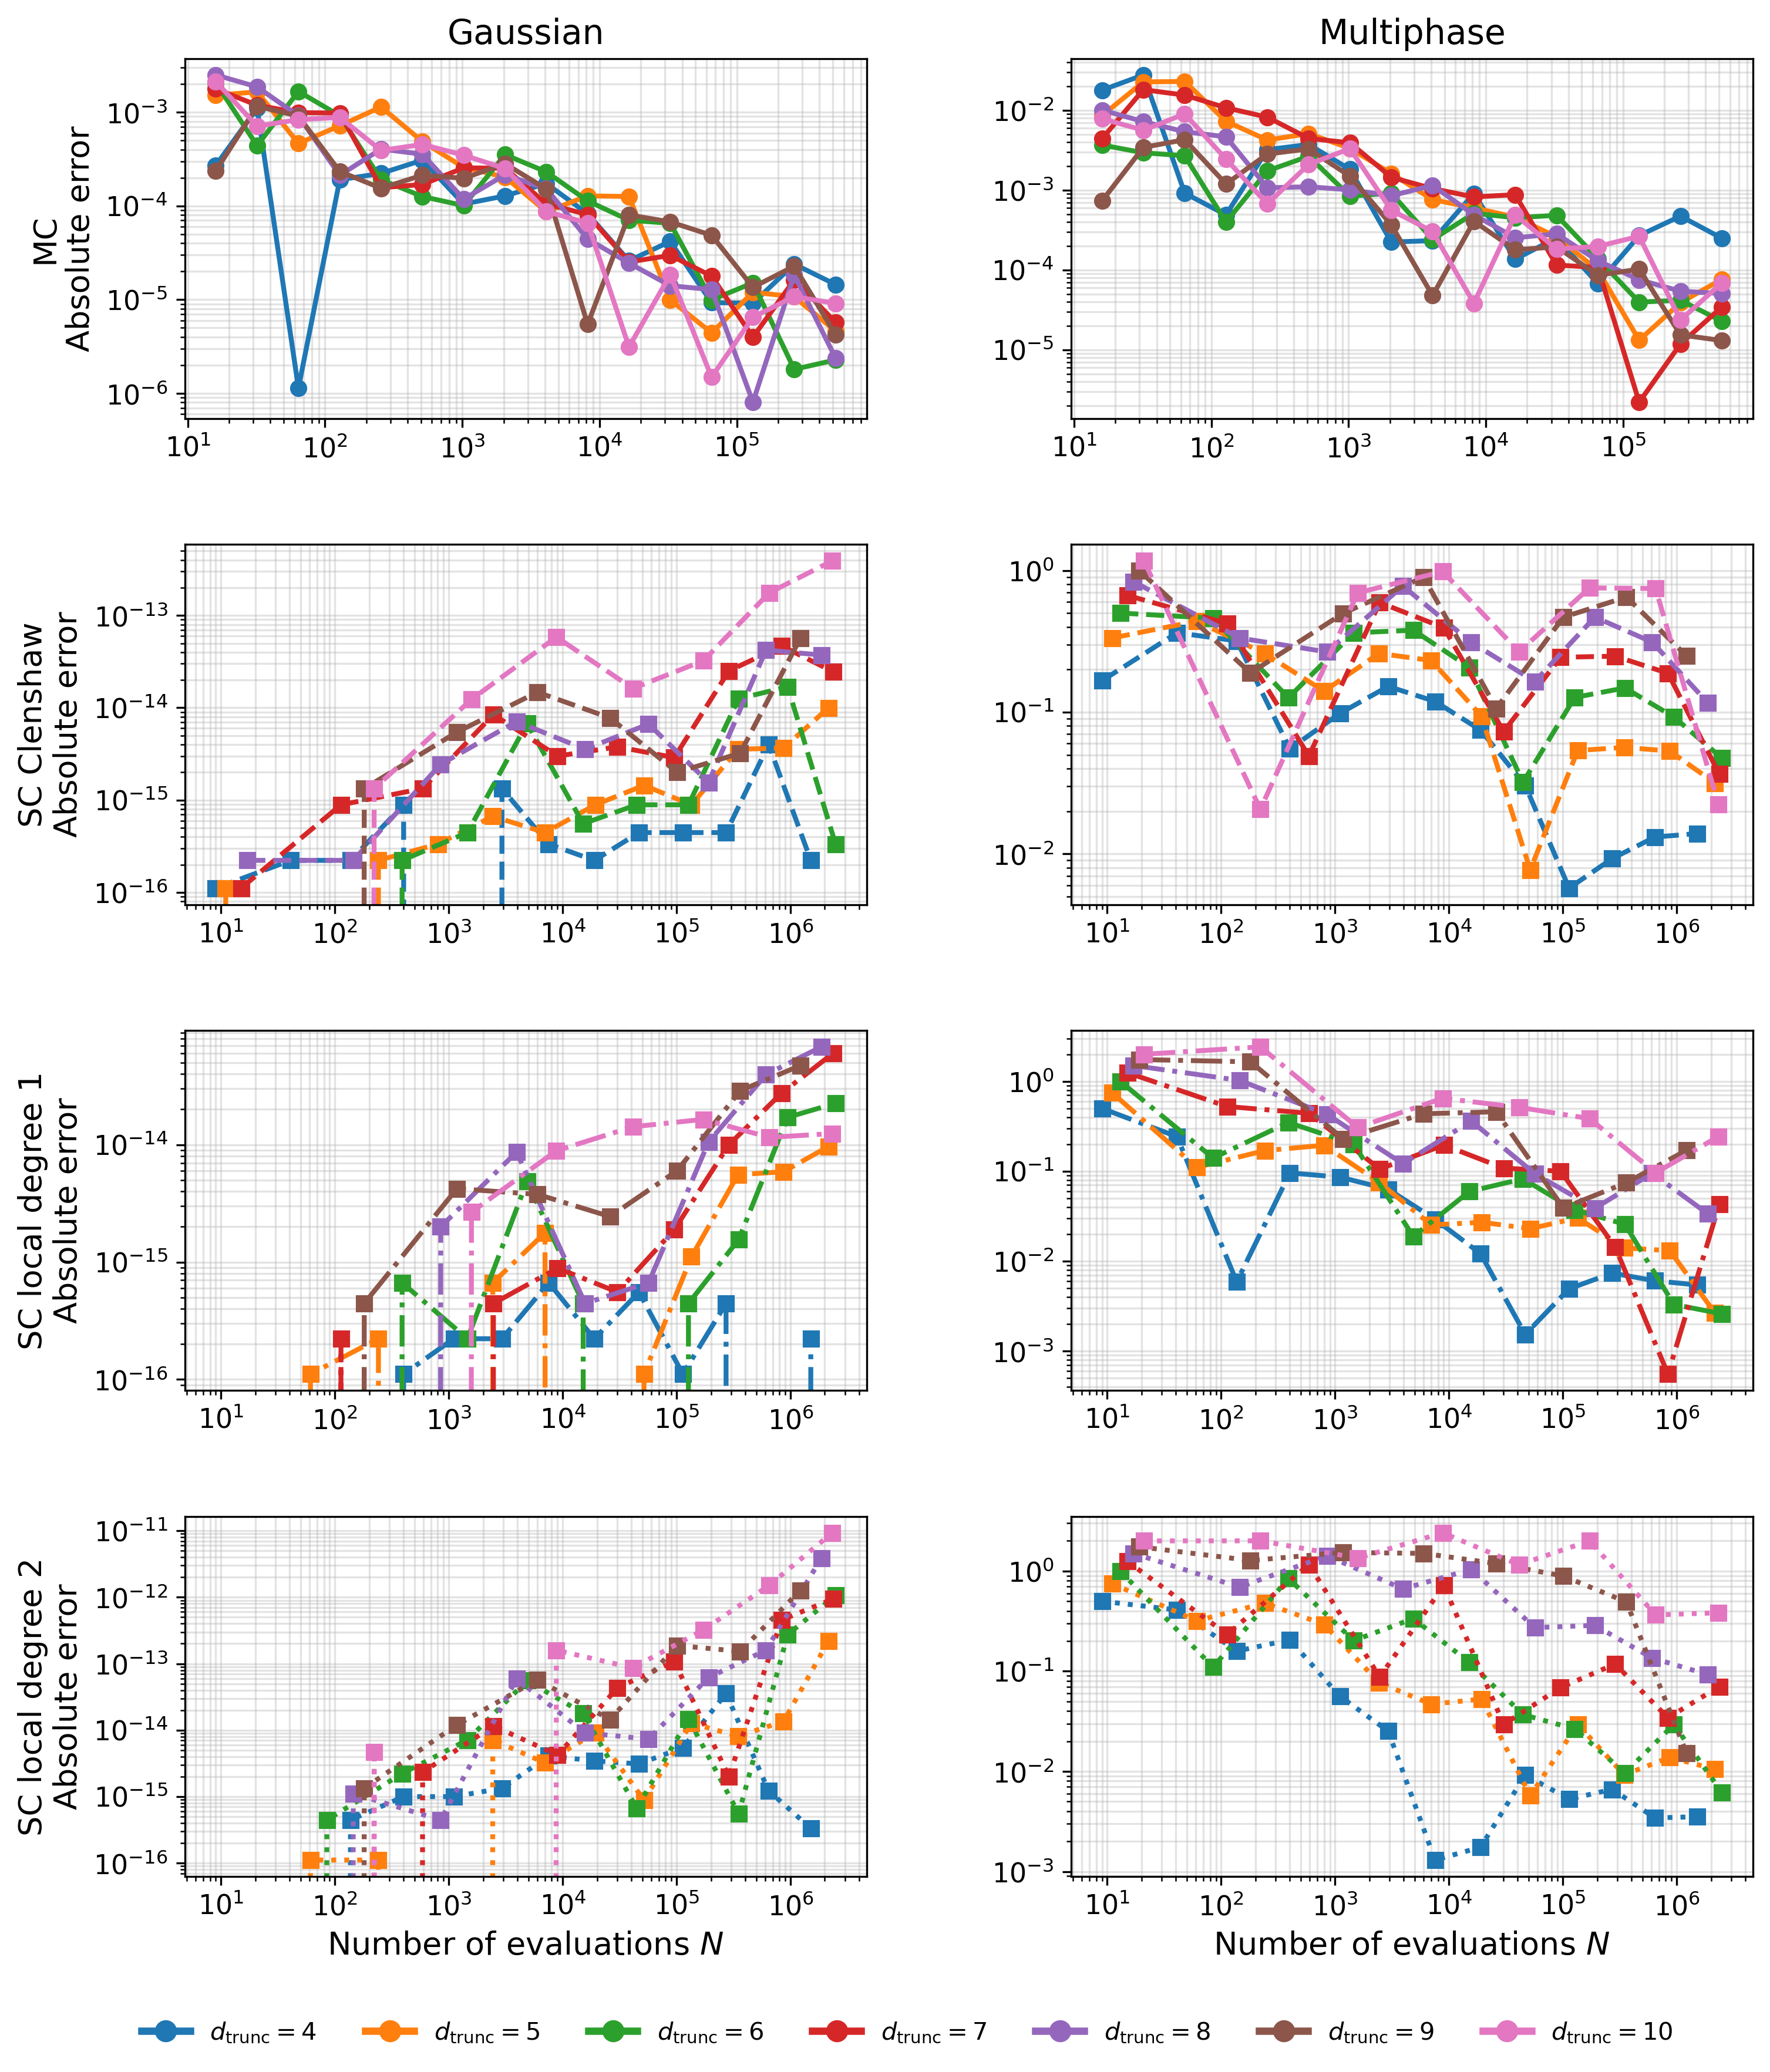

In [7]:
# Load if needed
df_test = pd.read_pickle("pklFiles/fieldQuantity.pkl")

methods = [
    "MC",
    "SCClenshaw",
    "SCLocalDegree1",
    "SCLocalDegree2",
]

cases = [
    "smooth Gaussian",
    "fixed 2-phase Gaussian",
]

case_titles = {
    "smooth Gaussian": "Gaussian",
    "fixed 2-phase Gaussian": "Multiphase",
}

method_titles = {
    "MC": "MC",
    "SCClenshaw": "SC Clenshaw",
    "SCLocalDegree1": "SC local degree 1",
    "SCLocalDegree2": "SC local degree 2",
}

dimensions = sorted(df_test["dimension"].unique())

cmap = plt.get_cmap("tab10")
dim_colors = {
    dim: cmap(i % 10)
    for i, dim in enumerate(dimensions)
}

markers = {
    "MC": "o",
    "SCClenshaw": "s",
    "SCLocalDegree1": "s",
    "SCLocalDegree2": "s",
}

linestyles = {
    "MC": "-",
    "SCClenshaw": "--",
    "SCLocalDegree1": "-.",
    "SCLocalDegree2": ":",
}

fig, axes = plt.subplots(
    len(methods),
    2,
    figsize=(10, 12),
    sharex=False,
    sharey=False,
)

for row, method in enumerate(methods):

    for col, case in enumerate(cases):

        ax = axes[row, col]

        for dim in dimensions:

            d = df_test[
                (df_test["method"] == method)
                & (df_test["case"] == case)
                & (df_test["dimension"] == dim)
            ].sort_values("N")

            if d.empty:
                continue

            ax.loglog(
                d["N"],
                d["absError"],
                marker=markers[method],
                linestyle=linestyles[method],
                linewidth=2.0,
                markersize=6,
                color=dim_colors[dim],
                label=rf"{method_titles[method]}, $d_{{\text{{trunc}}}}={int(dim)}$", 
            )

        ax.grid(True, which="both", alpha=0.35)

        if row == 0:
            ax.set_title(case_titles[case])

        if col == 0:
            ax.set_ylabel(method_titles[method] + "\nAbsolute error")

        if row == len(methods) - 1:
            ax.set_xlabel(r"Number of evaluations $N$")

handles, labels = axes[0, 0].get_legend_handles_labels()

dim_handles = [
    Line2D(
        [0],
        [0],
        color=dim_colors[dim],
        lw=3,
        marker="o",
        markersize=8,
        label=rf"$d_{{\text{{trunc}}}}={int(dim)}$",
    )
    for dim in dimensions
]

fig.legend(
    handles=dim_handles,
    loc="lower center",
    ncol=len(dimensions),
    frameon=False,
    bbox_to_anchor=(0.5, -0.00),
)


fig.subplots_adjust(
    left=0.09,
    right=0.98,
    top=0.95,
    bottom=0.09,
    wspace=0.30,
    hspace=0.35,
)
plt.show()

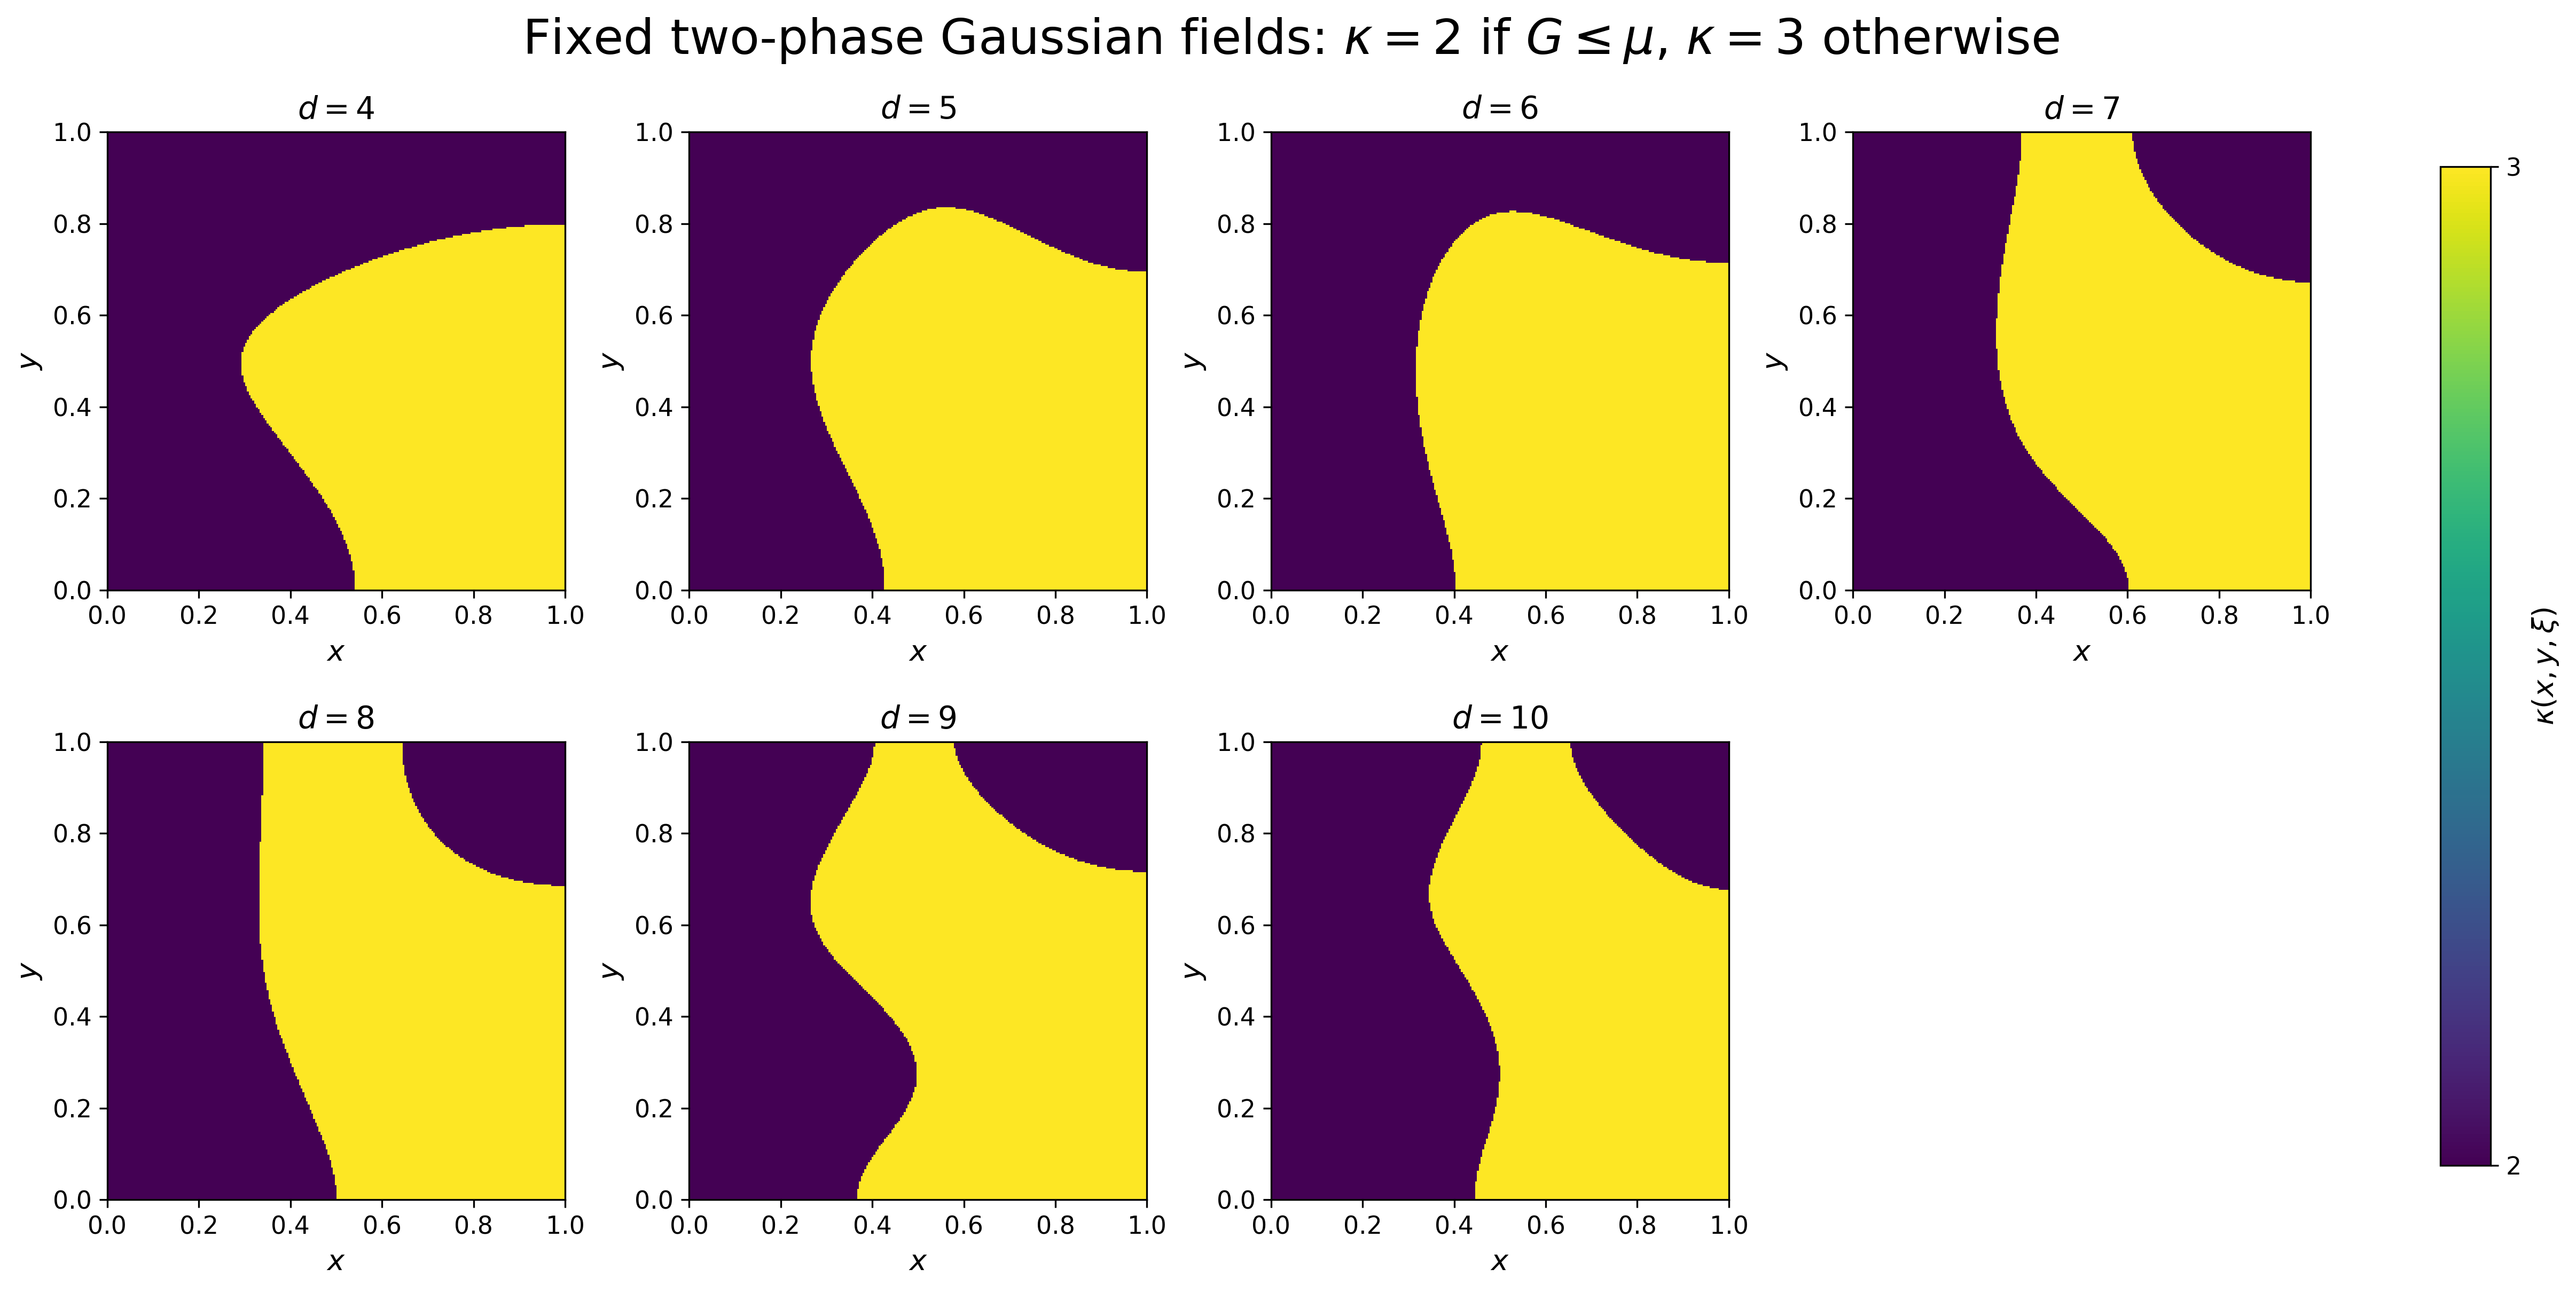

In [7]:
from math import ceil


plot_grid_size = 256
seed = 123

n_dims = len(dimensions)
ncols = 4
nrows = ceil(n_dims / ncols)

x = np.linspace(0.0, 1.0, plot_grid_size)
y = np.linspace(0.0, 1.0, plot_grid_size)
X, Y = np.meshgrid(x, y, indexing="ij")

fig, axes = plt.subplots(
    nrows,
    ncols,
    figsize=(4 * ncols, 4 * nrows),
    constrained_layout=True,
)

axes = np.asarray(axes).ravel()

for ax, dim in zip(axes, dimensions):

    rng = np.random.default_rng(seed)
    xi = rng.uniform(-1.0, 1.0, size=dim)

    field = GaussianFourierField(
        dim=dim,
        corrLength=corrLength,
        mu=mu,
        sigma=sigma,
    )

    G = field.evaluate(X, Y, xi)

    K = np.where(G <= mu, 2.0, 3.0)

    im = ax.imshow(
        K.T,
        origin="lower",
        extent=(0.0, 1.0, 0.0, 1.0),
        interpolation="nearest",
        vmin=2.0,
        vmax=3.0,
        aspect="equal",
    )

    ax.set_title(rf"$d={dim}$")
    ax.set_xlabel(r"$x$")
    ax.set_ylabel(r"$y$")

# Hide unused axes
for ax in axes[len(dimensions):]:
    ax.axis("off")

cbar = fig.colorbar(
    im,
    ax=axes[:len(dimensions)],
    shrink=0.85,
    ticks=[2.0, 3.0],
)

cbar.set_label(r"$\kappa(x,y,\xi)$")

fig.suptitle(
    r"Fixed two-phase Gaussian fields: $\kappa=2$ if $G\leq \mu$, $\kappa=3$ otherwise",
    fontsize=22,
)

plt.show()

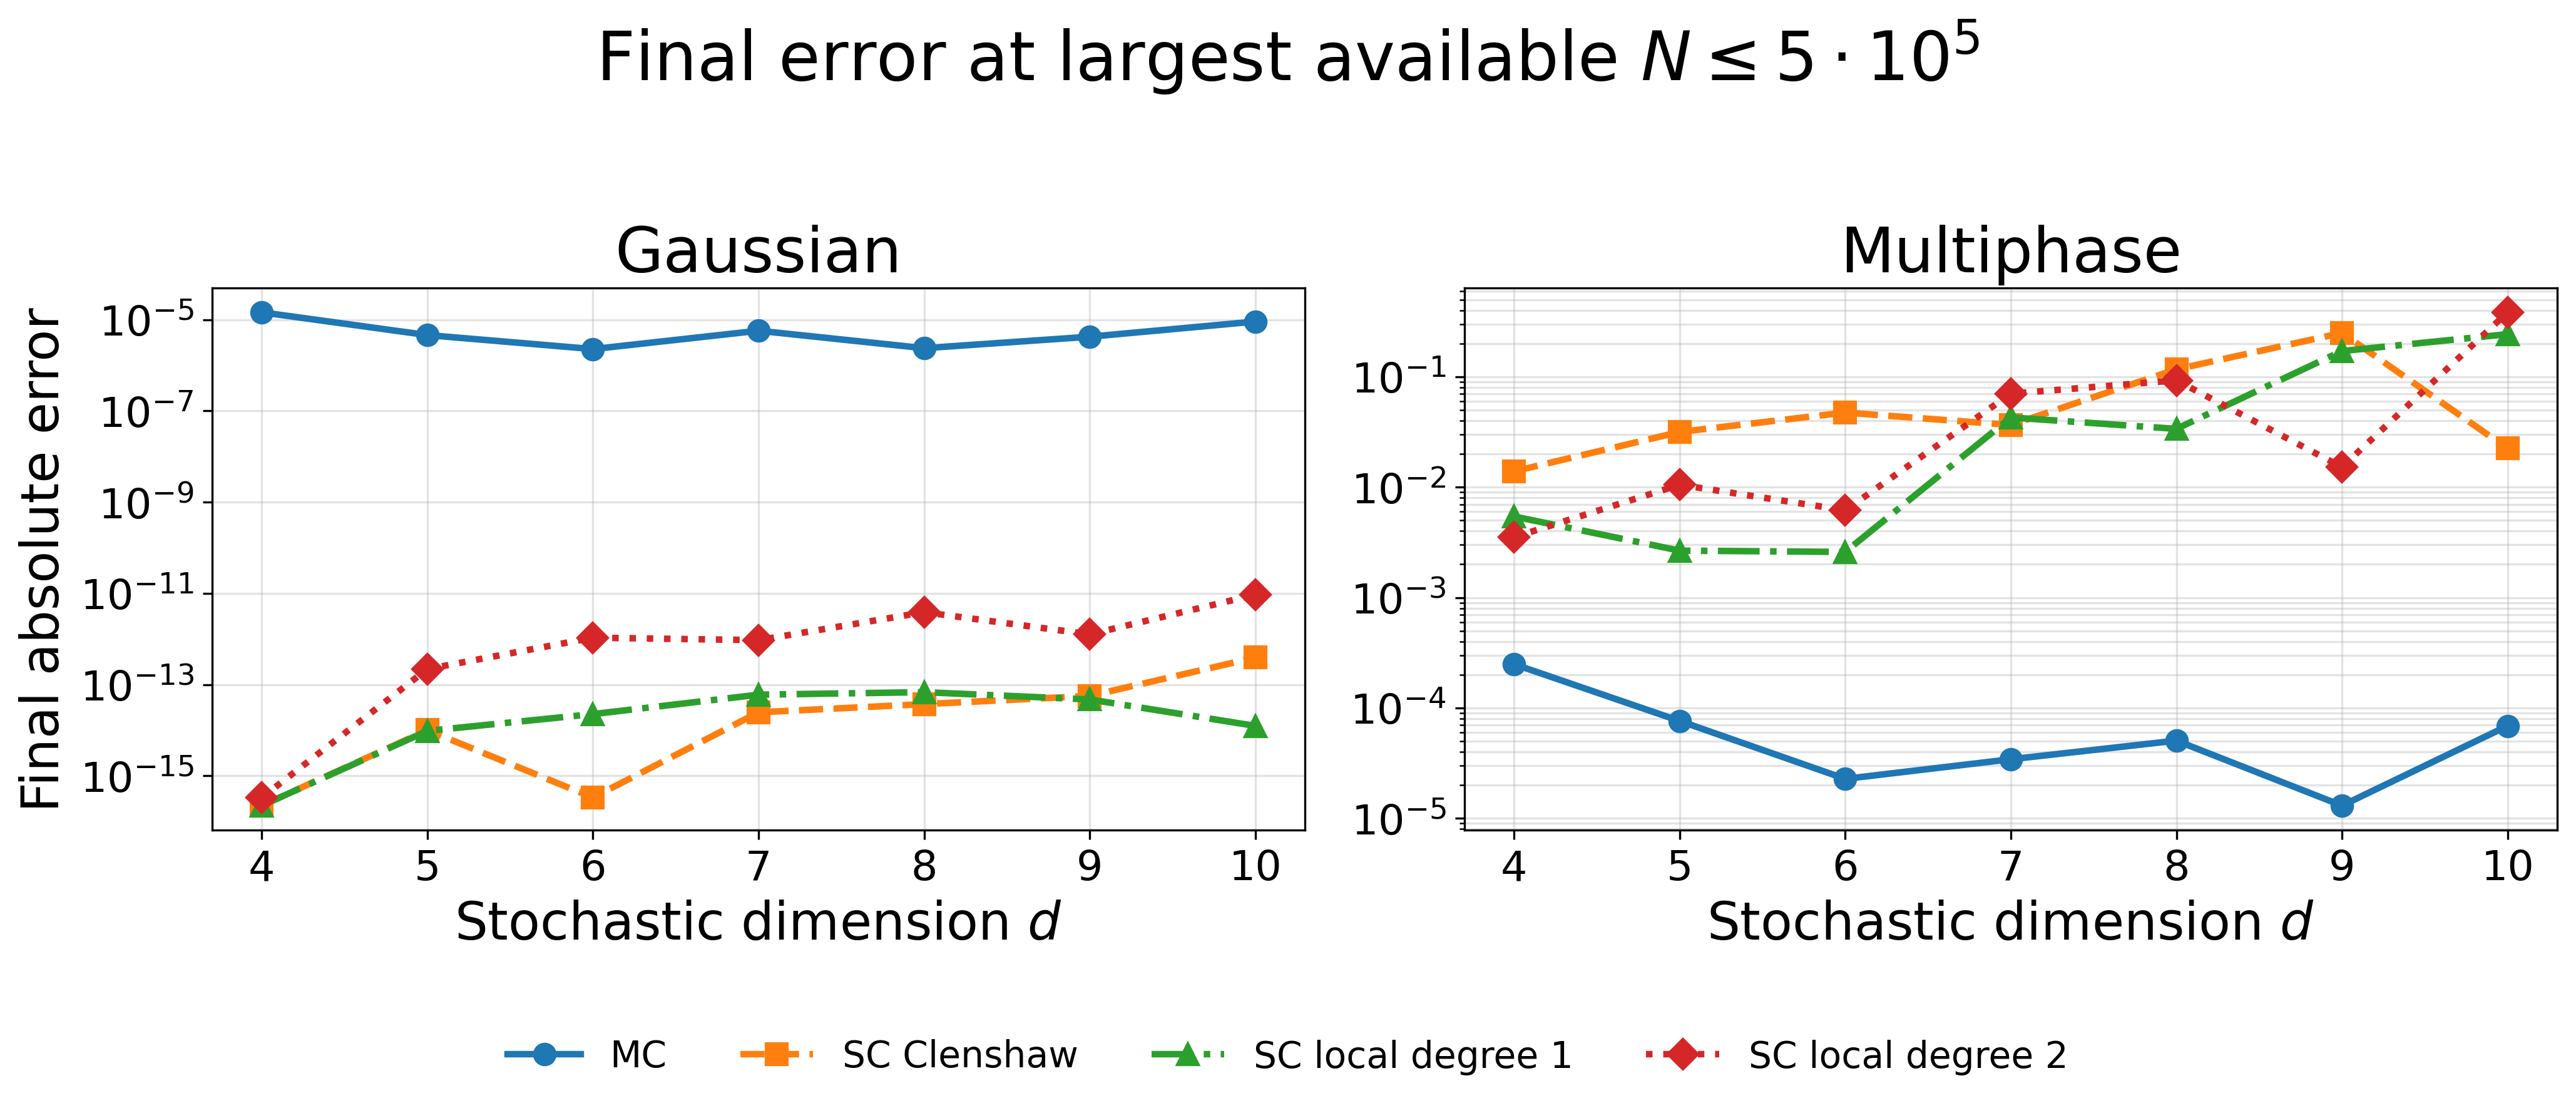

In [8]:
# ----------------------------------------------------------
# Load data
# ----------------------------------------------------------

df = pd.read_pickle("pklFiles/fieldQuantity.pkl")

# ----------------------------------------------------------
# Final error per dimension
# Take the largest N available for each method/case/dimension
# ----------------------------------------------------------

df_final = (
    df.sort_values("N")
      .groupby(["method", "case", "dimension"], as_index=False)
      .tail(1)
)

methods = [
    "MC",
    "SCClenshaw",
    "SCLocalDegree1",
    "SCLocalDegree2",
]

method_labels = {
    "MC": "MC",
    "SCClenshaw": "SC Clenshaw",
    "SCLocalDegree1": "SC local degree 1",
    "SCLocalDegree2": "SC local degree 2",
}

case_labels = {
    "smooth Gaussian": "Gaussian",
    "fixed 2-phase Gaussian": "Multiphase",
}

cases = [
    "smooth Gaussian",
    "fixed 2-phase Gaussian",
]

markers = {
    "MC": "o",
    "SCClenshaw": "s",
    "SCLocalDegree1": "^",
    "SCLocalDegree2": "D",
}

linestyles = {
    "MC": "-",
    "SCClenshaw": "--",
    "SCLocalDegree1": "-.",
    "SCLocalDegree2": ":",
}

plt.rcParams.update({
    "font.size": 16,
    "axes.labelsize": 20,
    "axes.titlesize": 24,
    "legend.fontsize": 14,
    "xtick.labelsize": 16,
    "ytick.labelsize": 16,
})

fig, axes = plt.subplots(
    1, 2,
    figsize=(14, 5),
    sharey=False,
)

for ax, case in zip(axes, cases):

    for method in methods:

        d = df_final[
            (df_final["case"] == case)
            & (df_final["method"] == method)
        ].sort_values("dimension")

        if d.empty:
            continue

        ax.semilogy(
            d["dimension"],
            d["absError"],
            marker=markers[method],
            linestyle=linestyles[method],
            linewidth=2.5,
            markersize=8,
            label=method_labels[method],
        )

    ax.set_title(case_labels[case])
    ax.set_xlabel(r"Stochastic dimension $d$")
    ax.set_xticks(sorted(df["dimension"].unique()))
    ax.grid(True, which="both", alpha=0.35)

axes[0].set_ylabel("Final absolute error")

fig.suptitle(
    r"Final error at largest available $N \leq 5\cdot 10^5$",
    fontsize=26,
    y=1.04,
)

handles, labels = axes[0].get_legend_handles_labels()
fig.legend(
    handles,
    labels,
    loc="lower center",
    ncol=4,
    frameon=False,
    bbox_to_anchor=(0.5, -0.12),
)

plt.tight_layout()
plt.show()